Objective:
The objective of this assignment is to compare the performance of Light GBM and XG Boost algorithms using the Titanic dataset.


Exploratory Data Analysis (EDA):
1.	Load the Titanic dataset using Python's pandas library.
2.	Check for missing values.
3.	Explore data distributions using histograms and box plots.
4.	Visualize relationships between features and survival using scatter plots and bar plots.


In [49]:
# load dataset
import pandas as pd
df=pd.read_csv('/content/Titanic_train.csv')
df.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


In [50]:
# checking for missing values
df.isnull().sum()

,0
PassengerId,0
Survived,0
Pclass,0
Name,0
Sex,0
Age,177
SibSp,0
Parch,0
Ticket,0
Fare,0


<Axes: >

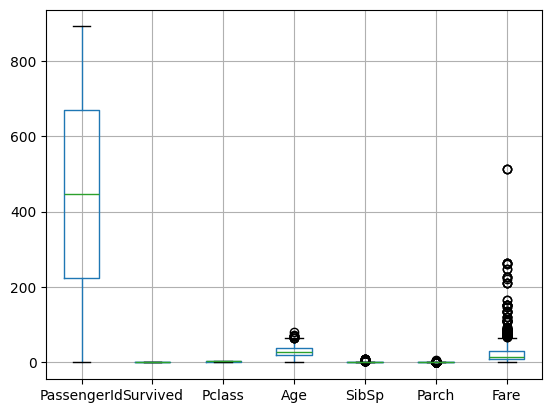

In [51]:
# data distribution
df.boxplot()

<Axes: ylabel='Count'>

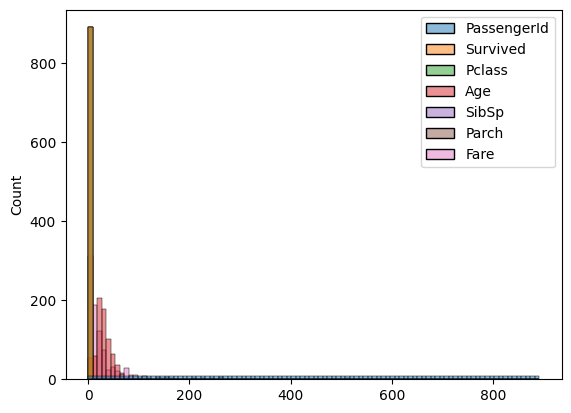

In [52]:
import seaborn as sns
sns.histplot(data=df,bins=100)

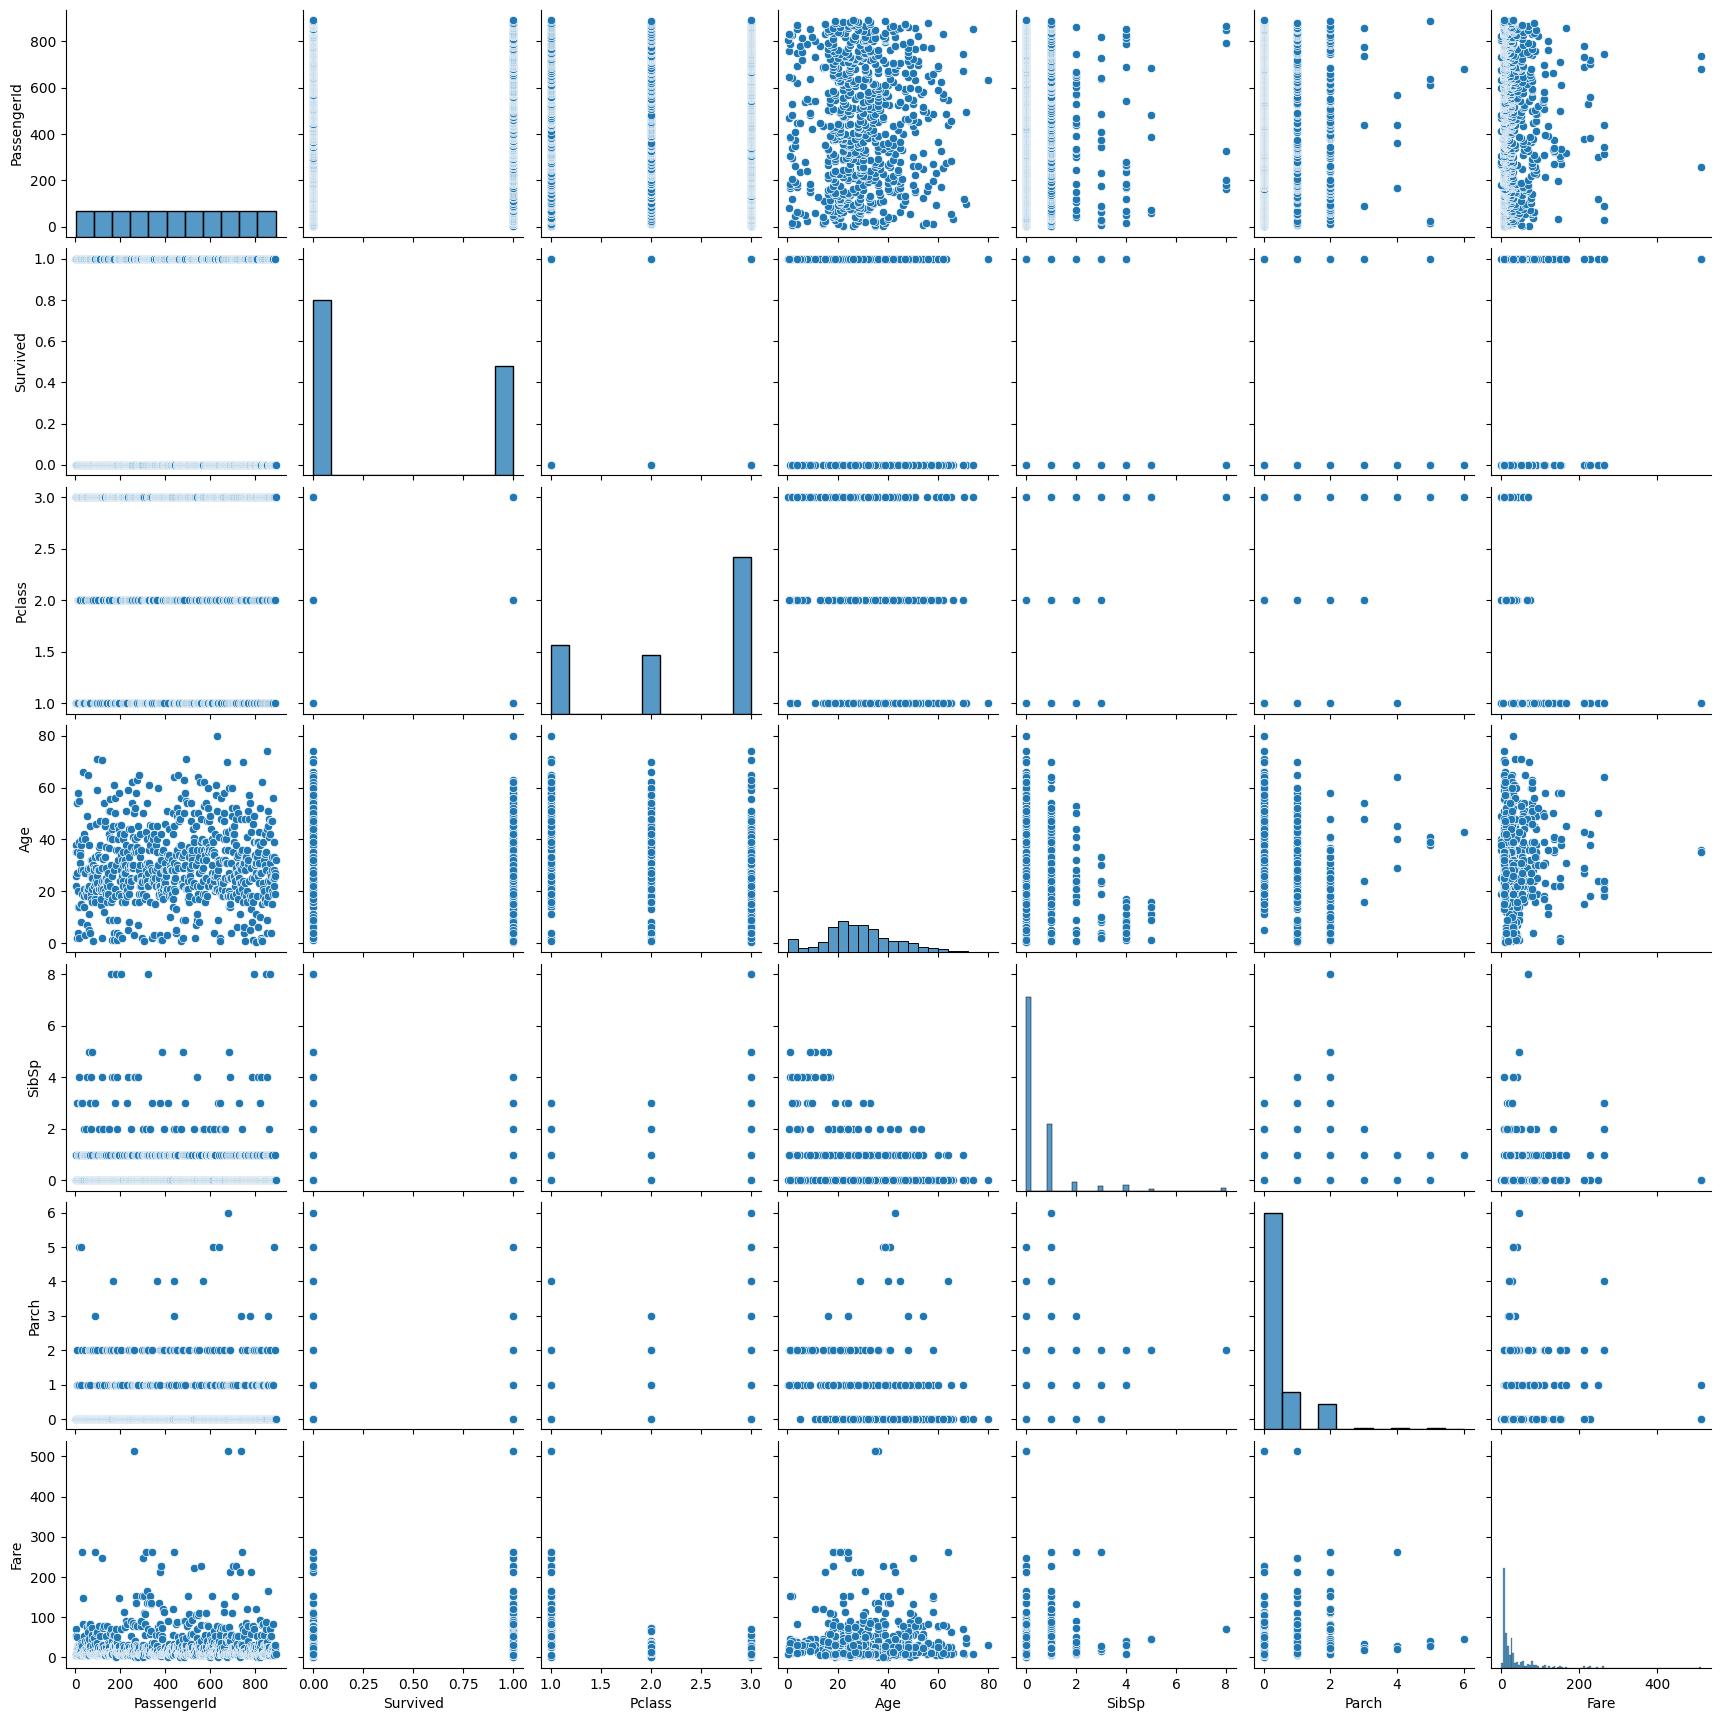

In [53]:
# visualize the relationship
sns.pairplot(df,kind='scatter')

<Axes: xlabel='Survived', ylabel='count'>

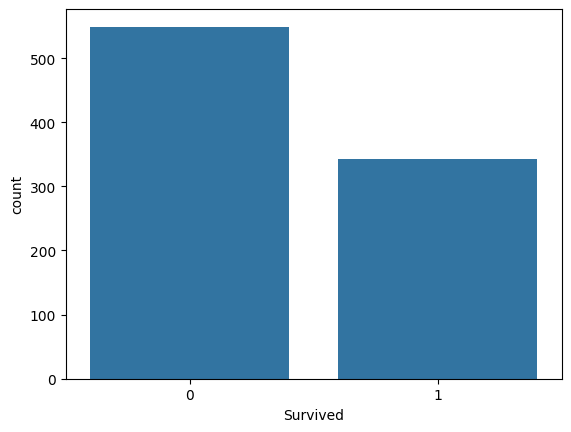

In [54]:
sns.countplot(data=df,x='Survived')

<Axes: xlabel='Sex', ylabel='count'>

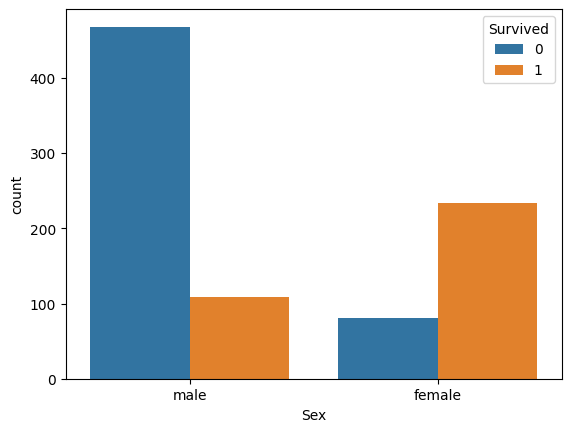

In [55]:
sns.countplot(data=df,x='Sex',hue='Survived')

<Axes: xlabel='SibSp', ylabel='count'>

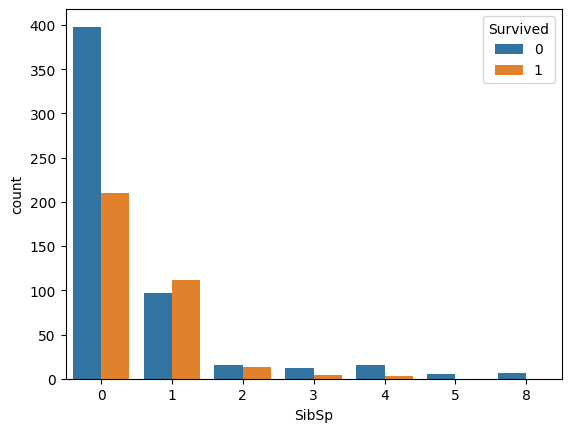

In [56]:
sns.countplot(data=df,x='SibSp',hue='Survived')

<Axes: xlabel='Parch', ylabel='count'>

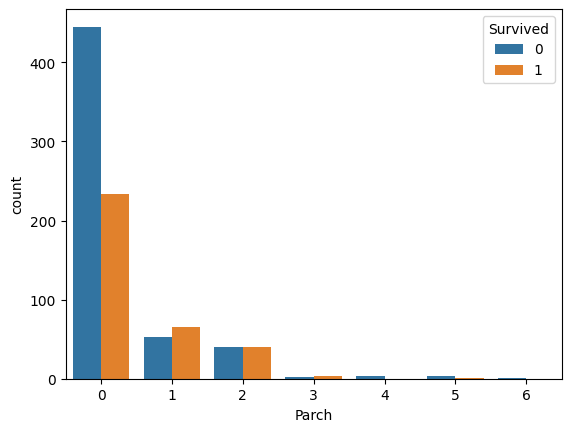

In [57]:
sns.countplot(data=df,x='Parch',hue='Survived')

<Axes: >

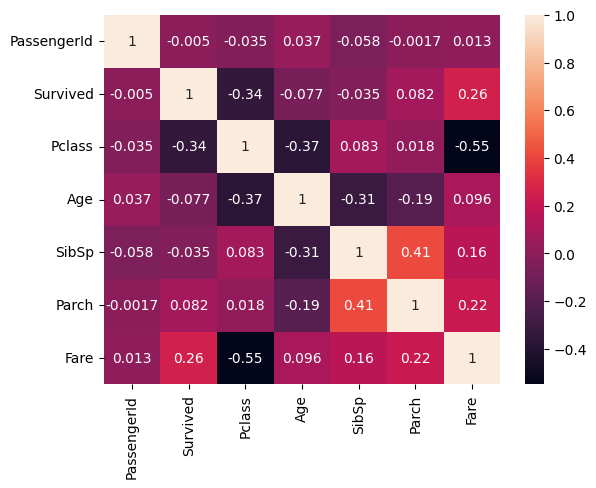

In [58]:
# correlation
corr=df.select_dtypes(include=['float','int']).corr()
sns.heatmap(corr,annot=True)

Data Preprocessing:
1.	Impute missing values.
2.	Encode categorical variables using one-hot encoding or label encoding.
3.	If needed you can apply more preprocessing methods on the given dataset.


In [59]:
# impute missing values
# Age,Cabin,Embarked
median_age=df['Age'].median()
mode_embarked=df['Embarked'].mode()

df.fillna({'Age':median_age,'Embarked':mode_embarked[0]},inplace=True)

In [60]:
df.drop(columns='Cabin',inplace=True)

In [61]:
# outlier capping
def outlier_capping(df,column):
  Q1=df[column].quantile(0.25)
  Q3=df[column].quantile(0.75)
  IQR=Q3-Q1
  lower_bound=Q1-1.5*IQR
  upper_bound=Q3+1.5*IQR
  df[column]=df[column].apply(lambda x:lower_bound if x<lower_bound else upper_bound if x>upper_bound else x)
for i in df.select_dtypes(include=['float','int']).columns:
  outlier_capping(df,i)

In [62]:
df.drop(columns=['Name','Ticket'],inplace=True)

In [63]:
df=pd.get_dummies(data=df,dtype='int')


In [64]:
df.drop(columns='PassengerId',inplace=True)

In [65]:
df.head()

,Survived,Pclass,Age,SibSp,Parch,Fare,Sex_female,Sex_male,Embarked_C,Embarked_Q,Embarked_S
0,0,3,22.0,1.0,0.0,7.2500,0,1,0,0,1
1,1,1,38.0,1.0,0.0,65.6344,1,0,1,0,0
2,1,3,26.0,0.0,0.0,7.9250,1,0,0,0,1
3,1,1,35.0,1.0,0.0,53.1000,1,0,0,0,1
4,0,3,35.0,0.0,0.0,8.0500,0,1,0,0,1


In [66]:
# target is survived
target=df['Survived']
features=df.drop(columns='Survived')

Building Predictive Models:
1.	Split the preprocessed dataset into training and testing sets.
2.	Choose appropriate evaluation metrics (e.g., accuracy, precision, recall, F1-score) for model evaluation.
3.	Build predictive models using LightGBM and XGBoost algorithms.
4.	Train the models on the training set and evaluate their performance on the testing set.
5.	Use techniques like cross-validation and hyperparameter tuning to optimize model performance.


In [67]:
# split the dataset
from sklearn.model_selection import train_test_split
x_train,x_test,y_train,y_test=train_test_split(features,target,train_size=0.75,random_state=100)

In [68]:
#define algorithms
# XGBM
!pip install xgboost

In [69]:
import xgboost as xgb
xgb_boost=xgb.XGBClassifier(n_estimators=100,learning_rate=0.5,min_child_weight=2,reg_alpha=10,
                            reg_lambda=10)

In [70]:
xgb_boost.fit(x_train,y_train)

XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=None, device=None, early_stopping_rounds=None,
              enable_categorical=False, eval_metric=None, feature_types=None,
              gamma=None, grow_policy=None, importance_type=None,
              interaction_constraints=None, learning_rate=0.5, max_bin=None,
              max_cat_threshold=None, max_cat_to_onehot=None,
              max_delta_step=None, max_depth=None, max_leaves=None,
              min_child_weight=2, missing=nan, monotone_constraints=None,
              multi_strategy=None, n_estimators=100, n_jobs=None,
              num_parallel_tree=None, random_state=None, ...)

In [71]:
y_pred=xgb_boost.predict(x_test)

In [72]:
from sklearn.metrics import accuracy_score,classification_report
accuracy_score(y_test,y_pred)

0.7937219730941704

In [73]:
print(classification_report(y_test,y_pred))

              precision    recall  f1-score   support

           0       0.76      0.94      0.84       127
           1       0.88      0.60      0.72        96

    accuracy                           0.79       223
   macro avg       0.82      0.77      0.78       223
weighted avg       0.81      0.79      0.79       223



In [74]:
#LGBM
!pip install lightgbm

In [75]:
import warnings
warnings.filterwarnings('ignore')
import lightgbm as lgb
light_gbm=lgb.LGBMClassifier(n_estimators=100,learning_rate=0.5,min_child_weight=2,reg_alpha=10,
                            reg_lambda=10,boosting_type='goss',top_rate=0.2,other_rate=0.3,min_bins=30)

In [76]:
light_gbm.fit(x_train,y_train)

[LightGBM] [Warning] Unknown parameter: min_bins
[LightGBM] [Warning] Found boosting=goss. For backwards compatibility reasons, LightGBM interprets this as boosting=gbdt, data_sample_strategy=goss.To suppress this warning, set data_sample_strategy=goss instead.
[LightGBM] [Warning] Unknown parameter: min_bins
[LightGBM] [Warning] Found boosting=goss. For backwards compatibility reasons, LightGBM interprets this as boosting=gbdt, data_sample_strategy=goss.To suppress this warning, set data_sample_strategy=goss instead.
[LightGBM] [Info] Number of positive: 246, number of negative: 422
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.000098 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 159
[LightGBM] [Info] Number of data points in the train set: 668, number of used features: 9
[LightGBM] [Info] Using GOSS
[LightGBM] [Info] [binary:Boost

LGBMClassifier(boosting_type='goss', learning_rate=0.5, min_bins=30,
               min_child_weight=2, other_rate=0.3, reg_alpha=10, reg_lambda=10,
               top_rate=0.2)

In [77]:
y_pred1=light_gbm.predict(x_test)

[LightGBM] [Warning] Unknown parameter: min_bins
[LightGBM] [Warning] Found boosting=goss. For backwards compatibility reasons, LightGBM interprets this as boosting=gbdt, data_sample_strategy=goss.To suppress this warning, set data_sample_strategy=goss instead.


In [78]:
accuracy_score(y_test,y_pred1)

0.8116591928251121

In [79]:
print(classification_report(y_test,y_pred1))

              precision    recall  f1-score   support

           0       0.79      0.91      0.85       127
           1       0.86      0.68      0.76        96

    accuracy                           0.81       223
   macro avg       0.82      0.80      0.80       223
weighted avg       0.82      0.81      0.81       223



In [80]:
# evalute on testing data
df1=pd.read_csv('/content/Titanic_test.csv')

In [81]:
df1.head()

,PassengerId,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,892,3,"Kelly, Mr. James",male,34.5,0,0,330911,7.8292,NaN,Q
1,893,3,"Wilkes, Mrs. James (Ellen Needs)",female,47.0,1,0,363272,7.0000,NaN,S
2,894,2,"Myles, Mr. Thomas Francis",male,62.0,0,0,240276,9.6875,NaN,Q
3,895,3,"Wirz, Mr. Albert",male,27.0,0,0,315154,8.6625,NaN,S
4,896,3,"Hirvonen, Mrs. Alexander (Helga E Lindqvist)",female,22.0,1,1,3101298,12.2875,NaN,S


In [82]:
#checking for missing values
df1.isnull().sum()

,0
PassengerId,0
Pclass,0
Name,0
Sex,0
Age,86
SibSp,0
Parch,0
Ticket,0
Fare,1
Cabin,327


In [83]:
df1.drop(columns=['PassengerId','Name','Ticket','Cabin'],inplace=True)

In [84]:
# impute missing values
median_age=df1['Age'].median()
median_fare=df1['Fare'].median()
df1.fillna({'Age':median_age,'Fare':median_fare},inplace=True)

In [85]:
#outliers_capping
def outlier_capping(df1,column):
  Q1=df1[column].quantile(0.25)
  Q3=df1[column].quantile(0.75)
  IQR=Q3-Q1
  lower_bound=Q1-1.5*IQR
  upper_bound=Q3+1.5*IQR
  df1[column]=df1[column].apply(lambda x:lower_bound if x<lower_bound else upper_bound if x>upper_bound else x)
for i in df1.select_dtypes(include=['float','int']).columns:
  outlier_capping(df1,i)

In [86]:
#labeling
df1=pd.get_dummies(data=df1,dtype='int')

In [87]:
df1.head()

,Pclass,Age,SibSp,Parch,Fare,Sex_female,Sex_male,Embarked_C,Embarked_Q,Embarked_S
0,3,34.500,0.0,0.0,7.8292,0,1,0,1,0
1,3,47.000,1.0,0.0,7.0000,1,0,0,0,1
2,2,54.875,0.0,0.0,9.6875,0,1,0,1,0
3,3,27.000,0.0,0.0,8.6625,0,1,0,0,1
4,3,22.000,1.0,0.0,12.2875,1,0,0,0,1


In [88]:
# xgbm
y_pred_xgbm=xgb_boost.predict(df1)

In [89]:
y_pred_xgbm

array([0, 0, 0, 0, 1, 0, 1, 0, 1, 0, 0, 0, 1, 0, 1, 1, 0, 0, 0, 0, 0, 0,
       1, 0, 1, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1,
       1, 0, 0, 0, 1, 0, 0, 0, 1, 1, 0, 0, 0, 0, 0, 1, 0, 0, 0, 1, 0, 1,
       1, 0, 0, 1, 1, 0, 0, 0, 1, 0, 0, 1, 0, 1, 0, 0, 0, 0, 0, 0, 1, 0,
       1, 0, 1, 0, 1, 0, 0, 0, 1, 0, 0, 0, 1, 0, 0, 0, 1, 0, 0, 0, 0, 0,
       0, 1, 1, 1, 1, 0, 0, 1, 0, 1, 1, 0, 1, 0, 0, 1, 0, 1, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0,
       0, 0, 1, 0, 0, 1, 1, 0, 1, 0, 0, 1, 0, 0, 1, 0, 0, 0, 0, 0, 0, 1,
       1, 0, 1, 1, 0, 0, 1, 0, 1, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 1, 0, 0, 1, 0, 0, 1, 0, 1, 0, 0, 0, 0, 1, 0, 0, 1, 0, 1, 0,
       1, 0, 1, 0, 1, 1, 0, 1, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 1, 1, 1, 1,
       0, 0, 0, 0, 1, 0, 1, 1, 1, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 1, 1,
       0, 0, 0, 0, 0, 0, 0, 0, 1, 1, 0, 1, 0, 0, 0, 0, 0, 0, 1, 1, 1, 0,
       0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 1, 0, 0, 0, 0,

In [90]:
# lgbm
light_gbm.predict(df1)

[LightGBM] [Warning] Unknown parameter: min_bins
[LightGBM] [Warning] Found boosting=goss. For backwards compatibility reasons, LightGBM interprets this as boosting=gbdt, data_sample_strategy=goss.To suppress this warning, set data_sample_strategy=goss instead.


array([0, 0, 0, 0, 0, 0, 1, 0, 1, 0, 0, 0, 1, 0, 1, 1, 0, 0, 1, 1, 0, 0,
       1, 1, 1, 0, 1, 0, 0, 0, 0, 0, 1, 0, 1, 0, 1, 1, 0, 0, 0, 0, 0, 1,
       1, 0, 0, 0, 1, 1, 0, 0, 1, 1, 0, 0, 0, 0, 0, 1, 0, 0, 0, 1, 0, 1,
       1, 0, 0, 1, 1, 0, 1, 0, 1, 1, 0, 1, 0, 1, 1, 0, 0, 0, 0, 0, 1, 1,
       1, 1, 0, 0, 1, 0, 0, 0, 1, 0, 1, 0, 1, 0, 0, 0, 1, 0, 0, 0, 0, 0,
       0, 1, 1, 1, 1, 0, 0, 1, 1, 1, 1, 0, 1, 0, 0, 1, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 1, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0,
       0, 0, 1, 1, 0, 0, 1, 1, 1, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 1,
       1, 0, 1, 1, 0, 1, 1, 0, 1, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 1,
       0, 1, 1, 1, 0, 1, 0, 0, 1, 0, 1, 0, 0, 0, 0, 1, 0, 0, 1, 0, 1, 0,
       1, 0, 1, 0, 1, 1, 0, 1, 0, 0, 0, 1, 0, 0, 1, 0, 0, 0, 1, 1, 1, 1,
       0, 0, 0, 0, 1, 0, 1, 1, 1, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 1, 1,
       0, 0, 0, 0, 1, 0, 0, 0, 1, 1, 0, 1, 0, 0, 0, 0, 0, 1, 1, 1, 1, 0,
       0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 1, 0, 0, 0, 0,

In [91]:
#cross validation
from sklearn.model_selection import StratifiedKFold,cross_val_score
stra_kfold=StratifiedKFold(n_splits=10,shuffle=True)
cross_val_score(xgb_boost,features,target,scoring='accuracy',cv=stra_kfold).mean()

0.8025468164794007

In [92]:
# grid search
from sklearn.model_selection import GridSearchCV

In [93]:
params={'n_splits':[5,6,7,8,9,10]}
grid_search=GridSearchCV(xgb_boost,params)
grid_search.fit(x_train,y_train)


GridSearchCV(estimator=XGBClassifier(base_score=None, booster=None,
                                     callbacks=None, colsample_bylevel=None,
                                     colsample_bynode=None,
                                     colsample_bytree=None, device=None,
                                     early_stopping_rounds=None,
                                     enable_categorical=False, eval_metric=None,
                                     feature_types=None, gamma=None,
                                     grow_policy=None, importance_type=None,
                                     interaction_constraints=None,
                                     learning_rate=0.5, max_bin=None,
                                     max_cat_threshold=None,
                                     max_cat_to_onehot=None,
                                     max_delta_step=None, max_depth=None,
                                     max_leaves=None, min_child_weight=2,
                                     missing=nan, monotone_constraints=None,
                                     multi_strategy=None, n_estimators=100,
                                     n_jobs=None, num_parallel_tree=None,
                                     random_state=None, ...),
             param_grid={'n_splits': [5, 6, 7, 8, 9, 10]})

In [94]:
grid_search.best_params_

{'n_splits': 5}

Comparative Analysis:
1.	Compare the performance metrics (e.g., accuracy, precision, recall) of LightGBM and XGBoost models.
2.	Visualize and interpret the results to identify the strengths and weaknesses of each algorithm.


In [95]:
# xgbm
print(classification_report(y_test,y_pred))

              precision    recall  f1-score   support

           0       0.76      0.94      0.84       127
           1       0.88      0.60      0.72        96

    accuracy                           0.79       223
   macro avg       0.82      0.77      0.78       223
weighted avg       0.81      0.79      0.79       223



In [96]:
#lgbm
print(classification_report(y_test,y_pred1))

              precision    recall  f1-score   support

           0       0.79      0.91      0.85       127
           1       0.86      0.68      0.76        96

    accuracy                           0.81       223
   macro avg       0.82      0.80      0.80       223
weighted avg       0.82      0.81      0.81       223



Text(0.5, 1.0, 'confusion matrix')

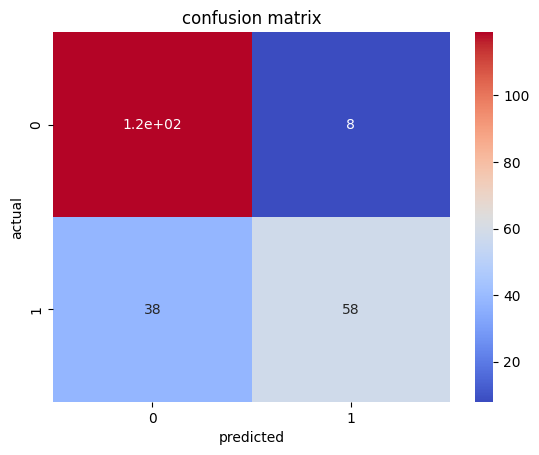

In [98]:
# visualize the results
# xgbm
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix
conf=confusion_matrix(y_test,y_pred)
sns.heatmap(conf,annot=True,cmap=plt.cm.coolwarm)
plt.xlabel('predicted')
plt.ylabel('actual')
plt.title('confusion matrix')

Text(0.5, 1.0, 'confusion matrix')

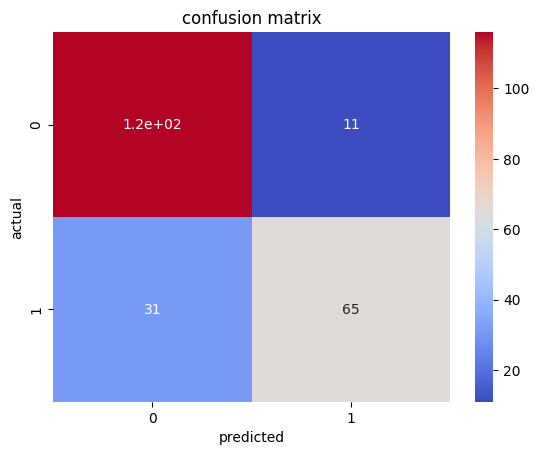

In [99]:
# visualize the results
# lgbm
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix
conf=confusion_matrix(y_test,y_pred1)
sns.heatmap(conf,annot=True,cmap=plt.cm.coolwarm)
plt.xlabel('predicted')
plt.ylabel('actual')
plt.title('confusion matrix')

Text(0.5, 1.0, 'xgbm_Roc_curve')

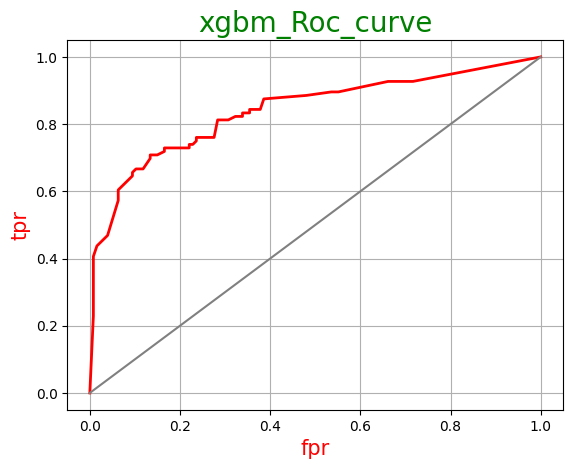

In [105]:
#roc curve
#xgbm
from sklearn.metrics import roc_auc_score,roc_curve
pred_proba1=xgb_boost.predict_proba(x_test)
sigmoid=pred_proba1[:,1]
auc_score=roc_auc_score(y_test,sigmoid)
fpr,tpr,thr=roc_curve(y_test,sigmoid)
plt.plot(fpr,tpr,color='red',linewidth=2,label=f'AUC_score : {auc_score:.2f}')
plt.plot([0,1],color='grey')
plt.grid()
plt.xlabel('fpr',color='red',size=15)
plt.ylabel('tpr',color='red',size=15)
plt.title('xgbm_Roc_curve',color='green',size=20)

[LightGBM] [Warning] Unknown parameter: min_bins
[LightGBM] [Warning] Found boosting=goss. For backwards compatibility reasons, LightGBM interprets this as boosting=gbdt, data_sample_strategy=goss.To suppress this warning, set data_sample_strategy=goss instead.


Text(0.5, 1.0, 'lgbm_Roc_curve')

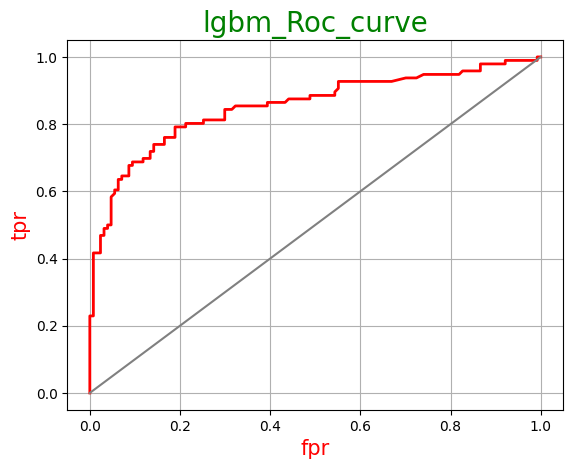

In [107]:
#roc curve
#lgbm
from sklearn.metrics import roc_auc_score,roc_curve
pred_proba1=light_gbm.predict_proba(x_test)
sigmoid=pred_proba1[:,1]
auc_score=roc_auc_score(y_test,sigmoid)
fpr,tpr,thr=roc_curve(y_test,sigmoid)
plt.plot(fpr,tpr,color='red',linewidth=2,label=f'AUC_score : {auc_score:.2f}')
plt.plot([0,1],color='grey')
plt.grid()
plt.xlabel('fpr',color='red',size=15)
plt.ylabel('tpr',color='red',size=15)
plt.title('lgbm_Roc_curve',color='green',size=20)

In [108]:
'''
Through these classification report and visualization , lgbm gives the better performance compared to xgbm.
'''

'\nThrough these classification report and visualization , lgbm gives the better performance compared to xgbm.\n'